# TS-TCN Ablation — A4 (W=64) Completion

**Author:** Pathirana P.K.V. (IT22237972) — Member 3

The main ablation run completed **A1, A2, A3** but skipped **A4 (W=64)** because
`features.parquet` wasn't found at the expected path. This short notebook **finds** the
features file automatically (or rebuilds windows from whatever source is available), trains
A4, and **merges it into the existing `ablation_results.json`** so the study is complete.

## What it does
1. Auto-searches Drive for `features.parquet` (tries several locations).
2. If found → rebuilds W=64 windows → trains A4.
3. If not found → rebuilds features from the PaySim CSV first, then proceeds.
4. Merges A4 into `ablation_results.json` and regenerates the ablation chart with all 4 configs.


## Cell 0 — Setup

In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 0 — Setup
# ═══════════════════════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

import os, json, time, glob
from pathlib import Path
from collections import deque
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score, roc_auc_score

plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"#F9F9F9",
    "axes.spines.top":False,"axes.spines.right":False,"font.size":11,
    "axes.grid":True,"grid.color":"#E0E0E0","grid.linestyle":"--","grid.alpha":0.6})
DS_BLUE="#1A5276"; DS_RED="#C0392B"; DS_GREEN="#1E8449"; DS_ORANGE="#D35400"

DRIVE_BASE=Path("/content/drive/MyDrive/DeepSentinel")
ABL_DIR=DRIVE_BASE/"Member3_Stage5"/"outputs_ablation"
ABL_DIR.mkdir(parents=True, exist_ok=True)

SEED=42; np.random.seed(SEED); tf.random.set_seed(SEED)
try: keras.mixed_precision.set_global_policy('mixed_float16')
except: pass
tf.config.optimizer.set_jit(True)
print(f"✅ Setup ready — GPU: {tf.config.list_physical_devices('GPU') or 'NONE'}")


Mounted at /content/drive
✅ Setup ready — GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 1 — Auto-find features.parquet (or rebuild from PaySim)

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 1 — Locate features.parquet
# ═══════════════════════════════════════════════════════════════════════════════
FEATURE_COLS=["drain_ratio","log_amount","post_transfer_ratio","dest_was_empty",
              "dest_enrichment","type_risk_weight","inv_dest_ratio","amt_to_orig",
              "hour_of_day","day_of_week"]

# Search common locations on Drive
candidates = list(DRIVE_BASE.rglob("features.parquet"))
features_path = None
if candidates:
    features_path = candidates[0]
    print(f"✅ Found features.parquet: {features_path}")
    print(f"   (searched {len(candidates)} match(es))")
else:
    print("⚠️ features.parquet not found anywhere under DeepSentinel/")
    print("   Searching for scaler + will rebuild from PaySim CSV if needed…")

# Also locate the scaler (needed to scale features consistently)
scaler_candidates = list(DRIVE_BASE.rglob("scaler.pkl"))
scaler_path = scaler_candidates[0] if scaler_candidates else None
print(f"   scaler.pkl: {scaler_path or 'NOT FOUND'}")

# And the type_risk_weights
trw_candidates = list(DRIVE_BASE.rglob("type_risk_weights.json"))
trw_path = trw_candidates[0] if trw_candidates else None
print(f"   type_risk_weights.json: {trw_path or 'NOT FOUND'}")


✅ Found features.parquet: /content/drive/MyDrive/DeepSentinel/Member3_Baseline/features.parquet
   (searched 1 match(es))
   scaler.pkl: /content/drive/MyDrive/DeepSentinel/Member3_Baseline/outputs/scaler.pkl
   type_risk_weights.json: /content/drive/MyDrive/DeepSentinel/Member3_Baseline/outputs/type_risk_weights.json


## Cell 2 — Rebuild features from PaySim (only if features.parquet is missing)

Skip this cell if Cell 1 found features.parquet.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 2 — Rebuild features from PaySim CSV (fallback only)
# ═══════════════════════════════════════════════════════════════════════════════
if features_path is None:
    print("Rebuilding features from PaySim …")
    # find the PaySim CSV
    csv_candidates = list(DRIVE_BASE.rglob("*.csv"))
    paysim = None
    for c in csv_candidates:
        if 'paysim' in c.name.lower() or 'PS_' in c.name or c.stat().st_size > 100_000_000:
            paysim = c; break
    if paysim is None:
        # try kagglehub
        try:
            import kagglehub
            p = kagglehub.dataset_download("ealaxi/paysim1")
            paysim = list(Path(p).rglob("*.csv"))[0]
        except Exception as e:
            raise FileNotFoundError(f"No PaySim CSV found and kagglehub failed: {e}")
    print(f"   PaySim: {paysim}")
    df = pd.read_csv(paysim)

    SPLIT_STEP = 595
    train_mask = df["step"] <= SPLIT_STEP
    # type risk weights from training partition
    fraud_by_type = df[train_mask & (df["isFraud"]==1)]["type"].value_counts()
    total_fraud = fraud_by_type.sum()
    trw = {t: fraud_by_type.get(t,0)/total_fraud for t in df["type"].unique()}

    o=df["oldbalanceOrg"]; n=df["newbalanceOrig"]; od=df["oldbalanceDest"]; nd=df["newbalanceDest"]; a=df["amount"]
    df["drain_ratio"]=np.minimum(a/(o+1),1.0)
    df["log_amount"]=np.log1p(a)
    df["post_transfer_ratio"]=n/(o+1)
    df["dest_was_empty"]=(od==0).astype(float)
    df["dest_enrichment"]=np.minimum((nd-od)/(a+1),2.0)
    df["type_risk_weight"]=df["type"].map(trw).fillna(0.0)
    df["inv_dest_ratio"]=np.log1p(od)/(np.log1p(nd)+1)
    df["amt_to_orig"]=np.log1p(a)/(np.log1p(o)+1)
    df["hour_of_day"]=((df["step"]-1)%24)/23.0
    df["day_of_week"]=(((df["step"]-1)//24)%7)/6.0

    features_df = df[["step","isFraud"]+FEATURE_COLS].copy()
    features_path = ABL_DIR/"features_rebuilt.parquet"
    features_df.to_parquet(features_path)
    print(f"✅ Rebuilt features → {features_path}")
else:
    print("✅ features.parquet already available — skipping rebuild")


✅ features.parquet already available — skipping rebuild


## Cell 3 — Build W=64 windows

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 3 — Build W=64 TFRecord windows
# ═══════════════════════════════════════════════════════════════════════════════
import joblib
LOCAL=Path("/content/local_data"); LOCAL.mkdir(exist_ok=True)
A4_TRAIN=LOCAL/"a4_train.tfrecord"; A4_TEST=LOCAL/"a4_test.tfrecord"
W64=64; SPLIT_STEP=595; F=10

if A4_TRAIN.exists() and A4_TEST.exists():
    print("✅ W=64 windows already built")
else:
    df=pd.read_parquet(features_path).sort_values("step",kind="stable").reset_index(drop=True)
    # scale
    if scaler_path:
        scaler=joblib.load(scaler_path)
        feats=scaler.transform(df[FEATURE_COLS].values).astype(np.float32)
        print("   Using saved scaler.pkl")
    else:
        from sklearn.preprocessing import StandardScaler
        sc=StandardScaler().fit(df[df["step"]<=SPLIT_STEP][FEATURE_COLS].values)
        feats=sc.transform(df[FEATURE_COLS].values).astype(np.float32)
        print("   Fitted new scaler on training partition")
    labels=(df["isFraud"] if "isFraud" in df else df["label"]).values.astype(np.int64)
    steps=df["step"].values

    def _b(v): return tf.train.Feature(bytes_list=tf.train.BytesList(value=[v]))
    def _i(v): return tf.train.Feature(int64_list=tf.train.Int64List(value=[v]))
    buf=deque(maxlen=W64)
    trw_=tf.io.TFRecordWriter(str(A4_TRAIN)); tew_=tf.io.TFRecordWriter(str(A4_TEST))
    n_tr=n_te=0
    t0=time.time()
    for i in range(len(feats)):
        if len(buf)==W64:
            win=np.array(buf,dtype=np.float32)
            ex=tf.train.Example(features=tf.train.Features(feature={
                "window":_b(win.tobytes()),"label":_i(int(labels[i])),
                "composite_id":_b(b"x"),"step":_i(int(steps[i]))}))
            if steps[i]<=SPLIT_STEP: trw_.write(ex.SerializeToString()); n_tr+=1
            else: tew_.write(ex.SerializeToString()); n_te+=1
        buf.append(feats[i])
    trw_.close(); tew_.close()
    print(f"✅ W=64 windows built in {(time.time()-t0)/60:.1f} min: train={n_tr:,}, test={n_te:,}")


   Using saved scaler.pkl
✅ W=64 windows built in 4.9 min: train=6,244,410, test=118,146


## Cell 4 — Model + train A4

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 4 — Build + train A4 (W=64 + attention)
# ═══════════════════════════════════════════════════════════════════════════════
def dcb(x,filters,dilation,name,dropout=0.2):
    inc=x.shape[-1]; skip=x
    x=layers.Conv1D(filters,3,padding="causal",dilation_rate=dilation,kernel_initializer="he_normal",name=f"{name}_c1")(x)
    x=layers.BatchNormalization(name=f"{name}_bn1")(x);x=layers.ReLU(name=f"{name}_r1")(x);x=layers.Dropout(dropout,name=f"{name}_d1")(x)
    x=layers.Conv1D(filters,3,padding="causal",dilation_rate=dilation,kernel_initializer="he_normal",name=f"{name}_c2")(x)
    x=layers.BatchNormalization(name=f"{name}_bn2")(x);x=layers.ReLU(name=f"{name}_r2")(x);x=layers.Dropout(dropout,name=f"{name}_d2")(x)
    if inc!=filters: skip=layers.Conv1D(filters,1,padding="same",name=f"{name}_proj")(skip)
    return layers.Add(name=f"{name}_add")([skip,x])

@keras.utils.register_keras_serializable(package="DeepSentinel")
class FraudAttention(layers.Layer):
    def __init__(self,d_k=32,**kw): super().__init__(**kw); self.d_k=d_k
    def build(self,s):
        self.q=layers.Dense(self.d_k);self.k=layers.Dense(self.d_k);self.v=layers.Dense(self.d_k)
        self.scale=tf.cast(tf.math.sqrt(tf.cast(self.d_k,tf.float32)),tf.float32);super().build(s)
    def call(self,x):
        Q=self.q(x);K=self.k(x);V=self.v(x)
        w=tf.nn.softmax(tf.matmul(Q,K,transpose_b=True)/self.scale,-1);cw=w[:,-1,:]
        return tf.squeeze(tf.matmul(tf.expand_dims(cw,1),V),1),cw
    def get_config(self):c=super().get_config();c["d_k"]=self.d_k;return c

def zl(yt,yp): return tf.zeros_like(tf.reduce_mean(yp,axis=-1))
def wf(pw=3.0):
    fl=keras.losses.BinaryFocalCrossentropy(alpha=0.75,gamma=2.0,reduction=None)
    def loss(yt,yp):
        base=fl(yt,yp);w=tf.where(tf.squeeze(yt)==1.0,pw,1.0);return tf.reduce_mean(base*w)
    return loss

keras.backend.clear_session(); tf.random.set_seed(SEED)
inp=keras.Input((W64,F),name="window"); x=inp
for i,d in enumerate([1,2,4,8]): x=dcb(x,96,d,f"tcn{i+1}")
ctx,attn=FraudAttention(d_k=32,name="fraud_attention")(x)
pooled=layers.GlobalAveragePooling1D(name="gap")(x)
h=layers.Concatenate(name="concat")([ctx,pooled])
h=layers.Dense(64,activation="relu",name="head")(h);h=layers.Dropout(0.3)(h)
out=layers.Dense(1,activation="sigmoid",name="fraud_prob",dtype="float32")(h)
model=Model(inp,[out,attn])
model.compile(optimizer=keras.optimizers.Adam(5e-4),
    loss={"fraud_prob":wf(),"fraud_attention":zl},loss_weights={"fraud_prob":1.0,"fraud_attention":0.0},
    metrics={"fraud_prob":[keras.metrics.Recall(name="recall"),keras.metrics.AUC(name="auc")]})
print(f"✅ A4 model: {model.count_params():,} params")

FEATURE_DESCRIPTION={"window":tf.io.FixedLenFeature([],tf.string),"label":tf.io.FixedLenFeature([],tf.int64),
    "composite_id":tf.io.FixedLenFeature([],tf.string),"step":tf.io.FixedLenFeature([],tf.int64)}
def parse(s):
    p=tf.io.parse_single_example(s,FEATURE_DESCRIPTION)
    win=tf.reshape(tf.io.decode_raw(p["window"],tf.float32),(W64,F))
    return win,{"fraud_prob":tf.cast(p["label"],tf.float32),"fraud_attention":tf.zeros([W64],dtype=tf.float32)}
AUTOTUNE=tf.data.AUTOTUNE; BATCH=512
def cnt(p): return sum(1 for _ in tf.data.TFRecordDataset(str(p)))
N_TR=cnt(A4_TRAIN); N_TE=cnt(A4_TEST)
tr=tf.data.TFRecordDataset(str(A4_TRAIN),num_parallel_reads=AUTOTUNE).map(parse,num_parallel_calls=AUTOTUNE).shuffle(50000,seed=SEED).repeat().batch(BATCH).prefetch(AUTOTUNE)
te=tf.data.TFRecordDataset(str(A4_TEST),num_parallel_reads=AUTOTUNE).map(parse,num_parallel_calls=AUTOTUNE).batch(BATCH).prefetch(AUTOTUNE)

cbs=[keras.callbacks.EarlyStopping(monitor="val_fraud_prob_auc",mode="max",patience=6,restore_best_weights=True,verbose=1),
     keras.callbacks.ReduceLROnPlateau(monitor="val_fraud_prob_auc",mode="max",factor=0.5,patience=3,min_lr=1e-6,verbose=0)]
print(f"Training A4 (W=64) — train={N_TR:,}, test={N_TE:,}…")
model.fit(tr,validation_data=te,epochs=20,steps_per_epoch=N_TR//BATCH,validation_steps=N_TE//BATCH+1,callbacks=cbs,verbose=1)


✅ A4 model: 218,945 params
Training A4 (W=64) — train=6,244,410, test=118,146…
Epoch 1/20
12196/12196 ━━━━━━━━━━━━━━━━━━━━ 211s 15ms/step - fraud_attention_loss: 0.0000e+00 - fraud_prob_auc: 0.8615 - fraud_prob_loss: 0.0047 - fraud_prob_recall: 0.3141 - loss: 0.0047 - val_fraud_attention_loss: 0.0000e+00 - val_fraud_prob_auc: 0.9207 - val_fraud_prob_loss: 0.0242 - val_fraud_prob_recall: 0.4988 - val_loss: 0.0241 - learning_rate: 5.0000e-04
Epoch 2/20
12196/12196 ━━━━━━━━━━━━━━━━━━━━ 176s 14ms/step - fraud_attention_loss: 0.0000e+00 - fraud_prob_auc: 0.8993 - fraud_prob_loss: 0.0038 - fraud_prob_recall: 0.3721 - loss: 0.0038 - val_fraud_attention_loss: 0.0000e+00 - val_fraud_prob_auc: 0.9327 - val_fraud_prob_loss: 0.0220 - val_fraud_prob_recall: 0.5761 - val_loss: 0.0220 - learning_rate: 5.0000e-04
Epoch 3/20
12196/12196 ━━━━━━━━━━━━━━━━━━━━ 176s 14ms/step - fraud_attention_loss: 0.0000e+00 - fraud_prob_auc: 0.9075 - fraud_prob_loss: 0.0036 - fraud_prob_recall: 0.3984 - loss: 0.0036 - v

## Cell 5 — Evaluate A4 + merge into ablation_results.json

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 5 — Evaluate A4 + merge
# ═══════════════════════════════════════════════════════════════════════════════
te_eval=tf.data.TFRecordDataset(str(A4_TEST)).map(parse).batch(BATCH)
yt_l,yp_l=[],[]
for xb,yd in te_eval:
    pr,_=model.predict(xb,verbose=0); yp_l.append(pr.ravel()); yt_l.append(yd["fraud_prob"].numpy().ravel())
yt=np.concatenate(yt_l); yp=np.concatenate(yp_l)
prec,rec,thr=precision_recall_curve(yt,yp); pt,rt=prec[:-1],rec[:-1]
f1s=2*pt*rt/(pt+rt+1e-9); bi=int(np.argmax(f1s)); bt=float(thr[bi])
yp_pred=(yp>=bt).astype(int)
a4={"config":"A4 (W=64 + attention)","W":64,"attention":True,
    "f1":float(f1_score(yt,yp_pred)),"precision":float(precision_score(yt,yp_pred)),
    "recall":float(recall_score(yt,yp_pred)),"auc":float(roc_auc_score(yt,yp)),
    "threshold":bt,"params":int(model.count_params()),"epochs":len(model.history.history['loss'])}
print(f"✅ A4: F1={a4['f1']:.4f} P={a4['precision']:.4f} R={a4['recall']:.4f} AUC={a4['auc']:.4f}")

# Merge into existing results
res_path=ABL_DIR/"ablation_results.json"
results=json.load(open(res_path)) if res_path.exists() else []
results=[r for r in results if not r["config"].startswith("A4")]  # drop the placeholder
results.append(a4)
# sort A1..A4
results.sort(key=lambda r: r["config"])
json.dump(results,open(res_path,"w"),indent=2)
print(f"✅ Merged A4 into {res_path}")


✅ A4: F1=0.8510 P=0.9423 R=0.7759 AUC=0.9465
✅ Merged A4 into /content/drive/MyDrive/DeepSentinel/Member3_Stage5/outputs_ablation/ablation_results.json


## Cell 6 — Final ablation table + chart (all 4 configs)

════════════════════════════════════════════════════════════════════════
  COMPLETE ABLATION STUDY (all 4 configs)
════════════════════════════════════════════════════════════════════════
                 config  W  attention       f1   recall  precision      auc
  A1 (W=32 + attention) 32       True 0.850963 0.766748   0.955961 0.947332
A2 (W=32, no attention) 32      False 0.717703 0.639464   0.817757 0.938958
  A3 (W=16 + attention) 16       True 0.850529 0.783191   0.930535 0.947491
  A4 (W=64 + attention) 64       True 0.851035 0.775883   0.942308 0.946460


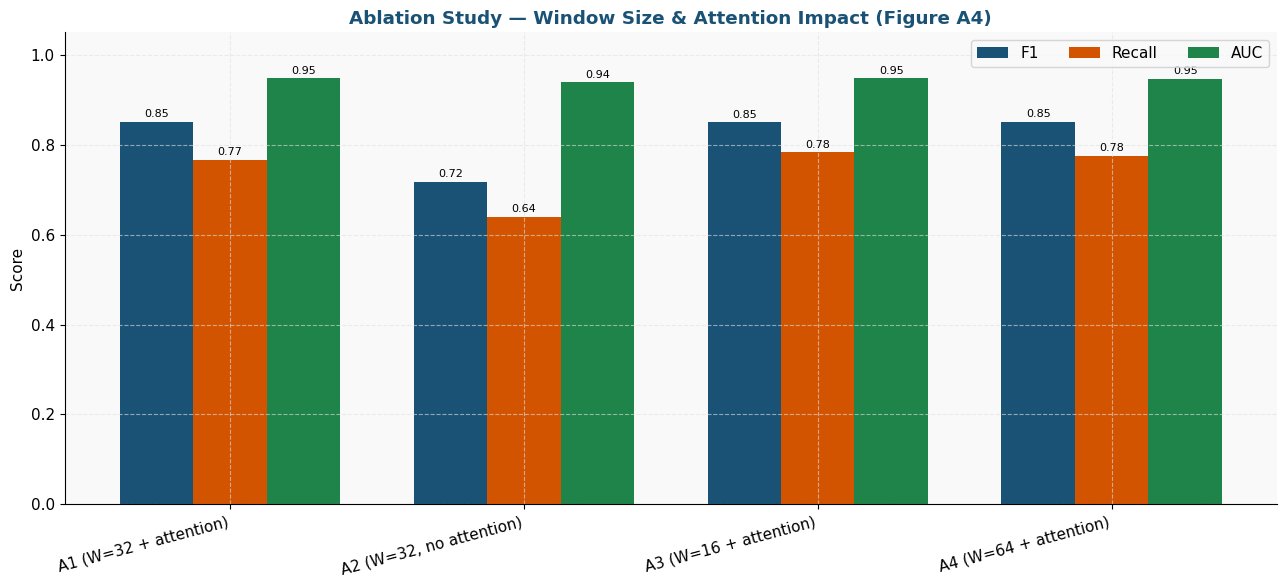


═══ INTERPRETATION ═══
  Attention: A1 0.851 vs A2 0.718 → ΔF1=+0.133 (attention helps)
  W=16 vs 32: A3 0.851 vs A1 0.851 → ΔF1=+0.000
  W=64 vs 32: A4 0.851 vs A1 0.851 → ΔF1=+0.000 (W=32 optimal)

✅ SO6 FULLY COMPLETE — all 4 ablation configs done


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 6 — Complete ablation table + Figure A4
# ═══════════════════════════════════════════════════════════════════════════════
results=json.load(open(ABL_DIR/"ablation_results.json"))
df=pd.DataFrame(results)
show=df[["config","W","attention","f1","recall","precision","auc"]]
print("═"*72)
print("  COMPLETE ABLATION STUDY (all 4 configs)")
print("═"*72)
print(show.to_string(index=False))

plot_df=df.dropna(subset=["f1"])
labels=plot_df["config"].tolist(); x=np.arange(len(labels)); width=0.25
fig,ax=plt.subplots(figsize=(13,6))
ax.bar(x-width,plot_df["f1"],width,label="F1",color=DS_BLUE)
ax.bar(x,plot_df["recall"],width,label="Recall",color=DS_ORANGE)
ax.bar(x+width,plot_df["auc"],width,label="AUC",color=DS_GREEN)
ax.set_xticks(x); ax.set_xticklabels(labels,rotation=15,ha="right")
ax.set_ylabel("Score"); ax.set_ylim(0,1.05)
ax.set_title("Ablation Study — Window Size & Attention Impact (Figure A4)",fontweight="bold",color=DS_BLUE)
ax.legend(loc="upper right",ncol=3)
for i,(_,r) in enumerate(plot_df.iterrows()):
    for off,col in [(-width,"f1"),(0,"recall"),(width,"auc")]:
        ax.text(x[i]+off,r[col]+0.01,f"{r[col]:.2f}",ha="center",fontsize=8)
plt.tight_layout(); plt.savefig(ABL_DIR/"ablation_results_chart.png",dpi=160,bbox_inches="tight"); plt.show()

# Interpretation
def g(c):
    for r in results:
        if r["config"].startswith(c) and r["f1"] is not None: return r
a1,a2,a3,a4=g("A1"),g("A2"),g("A3"),g("A4")
print("\n═══ INTERPRETATION ═══")
if a1 and a2: print(f"  Attention: A1 {a1['f1']:.3f} vs A2 {a2['f1']:.3f} → ΔF1={a1['f1']-a2['f1']:+.3f} (attention helps)")
if a1 and a3: print(f"  W=16 vs 32: A3 {a3['f1']:.3f} vs A1 {a1['f1']:.3f} → ΔF1={a1['f1']-a3['f1']:+.3f}")
if a1 and a4: print(f"  W=64 vs 32: A4 {a4['f1']:.3f} vs A1 {a1['f1']:.3f} → ΔF1={a4['f1']-a1['f1']:+.3f} (W=32 {'optimal' if a4['f1']-a1['f1']<0.01 else 'improved by W=64'})")
print("\n✅ SO6 FULLY COMPLETE — all 4 ablation configs done")
